## Imports

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from scipy.stats import pearsonr

import PyWGCNA

## Configurações

In [2]:
PROCESSED_DIR = Path("../../data/interim")
DESEQ_DIR = Path("../../data/interim/deseq2")
LOGCPM_PATH = PROCESSED_DIR / "microplastic_logcpm_filtered.csv"
METADATA_PATH = PROCESSED_DIR / "microplastic_metadata.csv"

# Saídas
WGCNA_DIR = Path("../../data/interim/wgcna")
WGCNA_DIR.mkdir(parents=True, exist_ok=True)

GENE_MODULES_PATH = WGCNA_DIR / "wgcna_gene_modules.csv"
MODULE_EIGENGENES_PATH = WGCNA_DIR / "wgcna_module_eigengenes.csv"
MODULE_EIGENGENES_TREATED_PATH = WGCNA_DIR / "wgcna_module_eigengenes_treated.csv"
MODULE_TRAIT_CORR_PATH = WGCNA_DIR / "wgcna_module_trait_correlations_treated.csv"
MODULE_TRAIT_PVAL_PATH = WGCNA_DIR / "wgcna_module_trait_pvalues_treated.csv"
MODULE_SUMMARY_PATH = WGCNA_DIR / "wgcna_module_summary.csv"

HEATMAP_PATH = WGCNA_DIR / "wgcna_module_trait_heatmap_treated.png"

## Carregamento dos Dados de DEG

In [3]:
logcpm_df = pd.read_csv(LOGCPM_PATH)
metadata_df = pd.read_csv(METADATA_PATH)

print("logCPM:", logcpm_df.shape)
print("metadata:", metadata_df.shape)

display(logcpm_df.head())
display(metadata_df.head())

logCPM: (15989, 25)
metadata: (24, 9)


,gene_id,CTR_1,CTR_2,CTR_3,MA1_1,MA1_2,MA1_3,MA100_1,MA100_2,MA100_3,...,MB100_3,MC1_1,MC1_2,MC1_3,MC100_1,MC100_2,MC100_3,MD1_1,MD1_2,MD1_3
0,ENSG00000000003,4.797306,4.724059,4.820733,4.655107,4.322105,4.645928,4.690951,4.697319,4.490118,...,4.935898,4.369827,4.438214,4.644916,4.603710,4.669377,4.783651,4.491358,4.809501,4.642756
1,ENSG00000000419,5.878139,5.179015,5.948045,5.755895,5.751875,5.628718,5.762351,5.960362,5.636034,...,5.835818,5.270056,5.821559,5.496394,5.798955,6.077030,5.599473,5.700585,5.906243,6.132563
2,ENSG00000000457,1.598040,3.313678,1.835379,1.713391,1.916360,1.752637,1.685682,1.892658,0.551253,...,2.292966,1.703389,1.071767,1.460843,2.029790,2.496567,2.451122,2.094427,1.931796,2.122500
3,ENSG00000000460,1.917690,1.632108,0.659941,0.433667,0.506306,1.781337,1.652155,0.336359,0.000000,...,1.424579,1.538066,1.969777,1.200561,0.927877,1.283326,1.678459,0.302888,1.585128,0.000000
4,ENSG00000001036,6.220797,6.215919,6.346495,6.164830,6.238335,6.984090,6.354802,6.114103,6.304642,...,6.550416,6.202338,6.269932,6.341710,6.610510,6.545199,6.540750,6.405801,6.540553,6.383806


,particle_type,particle_size_um,particle_size_nm,concentration_gL,is_control,treatment_status,sample_id,group,replicate
0,control,NaN,NaN,0.0,True,control,CTR_1,CTR,1
1,control,NaN,NaN,0.0,True,control,CTR_2,CTR,2
2,control,NaN,NaN,0.0,True,control,CTR_3,CTR,3
3,polystyrene,1.0,1000.0,0.1,False,treated,MA1_1,MA1,1
4,polystyrene,1.0,1000.0,0.1,False,treated,MA1_2,MA1,2


## Construção do WGCNA

In [4]:
# Preparação da matriz de expressão para PyWGCNA.
# A matriz em arquivo está em genes x amostras.
# Para o construtor WGCNA do PyWGCNA, deve-se usar amostras x genes.

sample_ids = metadata_df["sample_id"].tolist()
expr_sample_cols = [c for c in logcpm_df.columns if c != "gene_id"]

missing_in_expr = sorted(set(sample_ids) - set(expr_sample_cols))
missing_in_meta = sorted(set(expr_sample_cols) - set(sample_ids))

if missing_in_expr or missing_in_meta:
    raise ValueError(
        f"Inconsistência entre expressão e metadata.\n"
        f"Ausentes na expressão: {missing_in_expr}\n"
        f"Ausentes no metadata: {missing_in_meta}"
    )

# Reordena as colunas conforme a ordem do metadata
logcpm_df = logcpm_df[["gene_id"] + sample_ids]

# Formato esperado para WGCNA: amostras x genes
expr_wgcna = logcpm_df.set_index("gene_id").T
expr_wgcna.index.name = "sample_id"

# Metadata alinhado
metadata = metadata_df.set_index("sample_id").loc[expr_wgcna.index].copy()

print("Matriz para WGCNA:", expr_wgcna.shape)
print("Metadata alinhado:", metadata.shape)

display(expr_wgcna.iloc[:5, :5])
display(metadata.head())

Matriz para WGCNA: (24, 15989)
Metadata alinhado: (24, 8)


gene_id,ENSG00000000003,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000001036
sample_id,,,,,
CTR_1,4.797306,5.878139,1.598040,1.917690,6.220797
CTR_2,4.724059,5.179015,3.313678,1.632108,6.215919
CTR_3,4.820733,5.948045,1.835379,0.659941,6.346495
MA1_1,4.655107,5.755895,1.713391,0.433667,6.164830
MA1_2,4.322105,5.751875,1.916360,0.506306,6.238335


,particle_type,particle_size_um,particle_size_nm,concentration_gL,is_control,treatment_status,group,replicate
sample_id,,,,,,,,
CTR_1,control,NaN,NaN,0.0,True,control,CTR,1
CTR_2,control,NaN,NaN,0.0,True,control,CTR,2
CTR_3,control,NaN,NaN,0.0,True,control,CTR,3
MA1_1,polystyrene,1.0,1000.0,0.1,False,treated,MA1,1
MA1_2,polystyrene,1.0,1000.0,0.1,False,treated,MA1,2


In [5]:
# Preparação do metadata para PyWGCNA.

# Corrige possíveis problemas de tipo ao ler CSV
if metadata["is_control"].dtype == object:
    metadata["is_control"] = metadata["is_control"].astype(str).str.lower().map({
        "true": True,
        "false": False
    })

metadata["particle_size_um"] = pd.to_numeric(metadata["particle_size_um"], errors="coerce")
metadata["particle_size_nm"] = pd.to_numeric(metadata["particle_size_nm"], errors="coerce")
metadata["concentration_gL"] = pd.to_numeric(metadata["concentration_gL"], errors="coerce")

display(metadata.dtypes)
display(metadata.head())

particle_type        object
particle_size_um    float64
particle_size_nm    float64
concentration_gL    float64
is_control             bool
treatment_status     object
group                object
replicate             int64
dtype: object

,particle_type,particle_size_um,particle_size_nm,concentration_gL,is_control,treatment_status,group,replicate
sample_id,,,,,,,,
CTR_1,control,NaN,NaN,0.0,True,control,CTR,1
CTR_2,control,NaN,NaN,0.0,True,control,CTR,2
CTR_3,control,NaN,NaN,0.0,True,control,CTR,3
MA1_1,polystyrene,1.0,1000.0,0.1,False,treated,MA1,1
MA1_2,polystyrene,1.0,1000.0,0.1,False,treated,MA1,2


In [6]:
# Construção do objeto WGCNA

pyw = PyWGCNA.WGCNA(
    name="microplastic_wgcna",
    species="human",
    geneExp=expr_wgcna,
    sampleInfo=metadata,
    outputPath=str(WGCNA_DIR),
    save=True,
    TPMcutoff=0,
    powers=list(range(1, 11)) + list(range(12, 22, 2)),
    RsquaredCut=0.8,
    MeanCut=100,
    networkType="signed hybrid",
    TOMType="signed",
    minModuleSize=50,
    MEDissThres=0.2,
)

Saving data to be True, checking requirements ...


Pre-processing...
	Detecting genes and samples with too many missing values...
	Done pre-processing..

Run WGCNA...
pickSoftThreshold: calculating connectivity for given powers...
will use block size  2798
    Power  SFT.R.sq     slope truncated R.sq      mean(k)    median(k)  \
0       1  0.031739 -0.669413       0.848292  1694.689668  1621.599049   
1       2  0.671499 -2.232547       0.922791   540.484016   467.940758   
2       3  0.893053 -2.345353       0.974224    217.81808   164.739036   
3       4  0.925864 -2.221064       0.978428   102.640954    65.991944   
4       5  0.920782 -2.101386       0.971407    54.251442    29.001438   
5       6  0.929389 -1.952238       0.978824    31.321238    13.681366   
6       7  0.928092 -1.849001       0.978838    19.386816      6.84876   
7       8  0.926312 -1.768365       0.981403    12.688992     3.606507   
8       9  0.936075 -1.685301       0.988311     8.690633     1.984145   
9      10  0.939191 -1.626214       0.990397     6.178

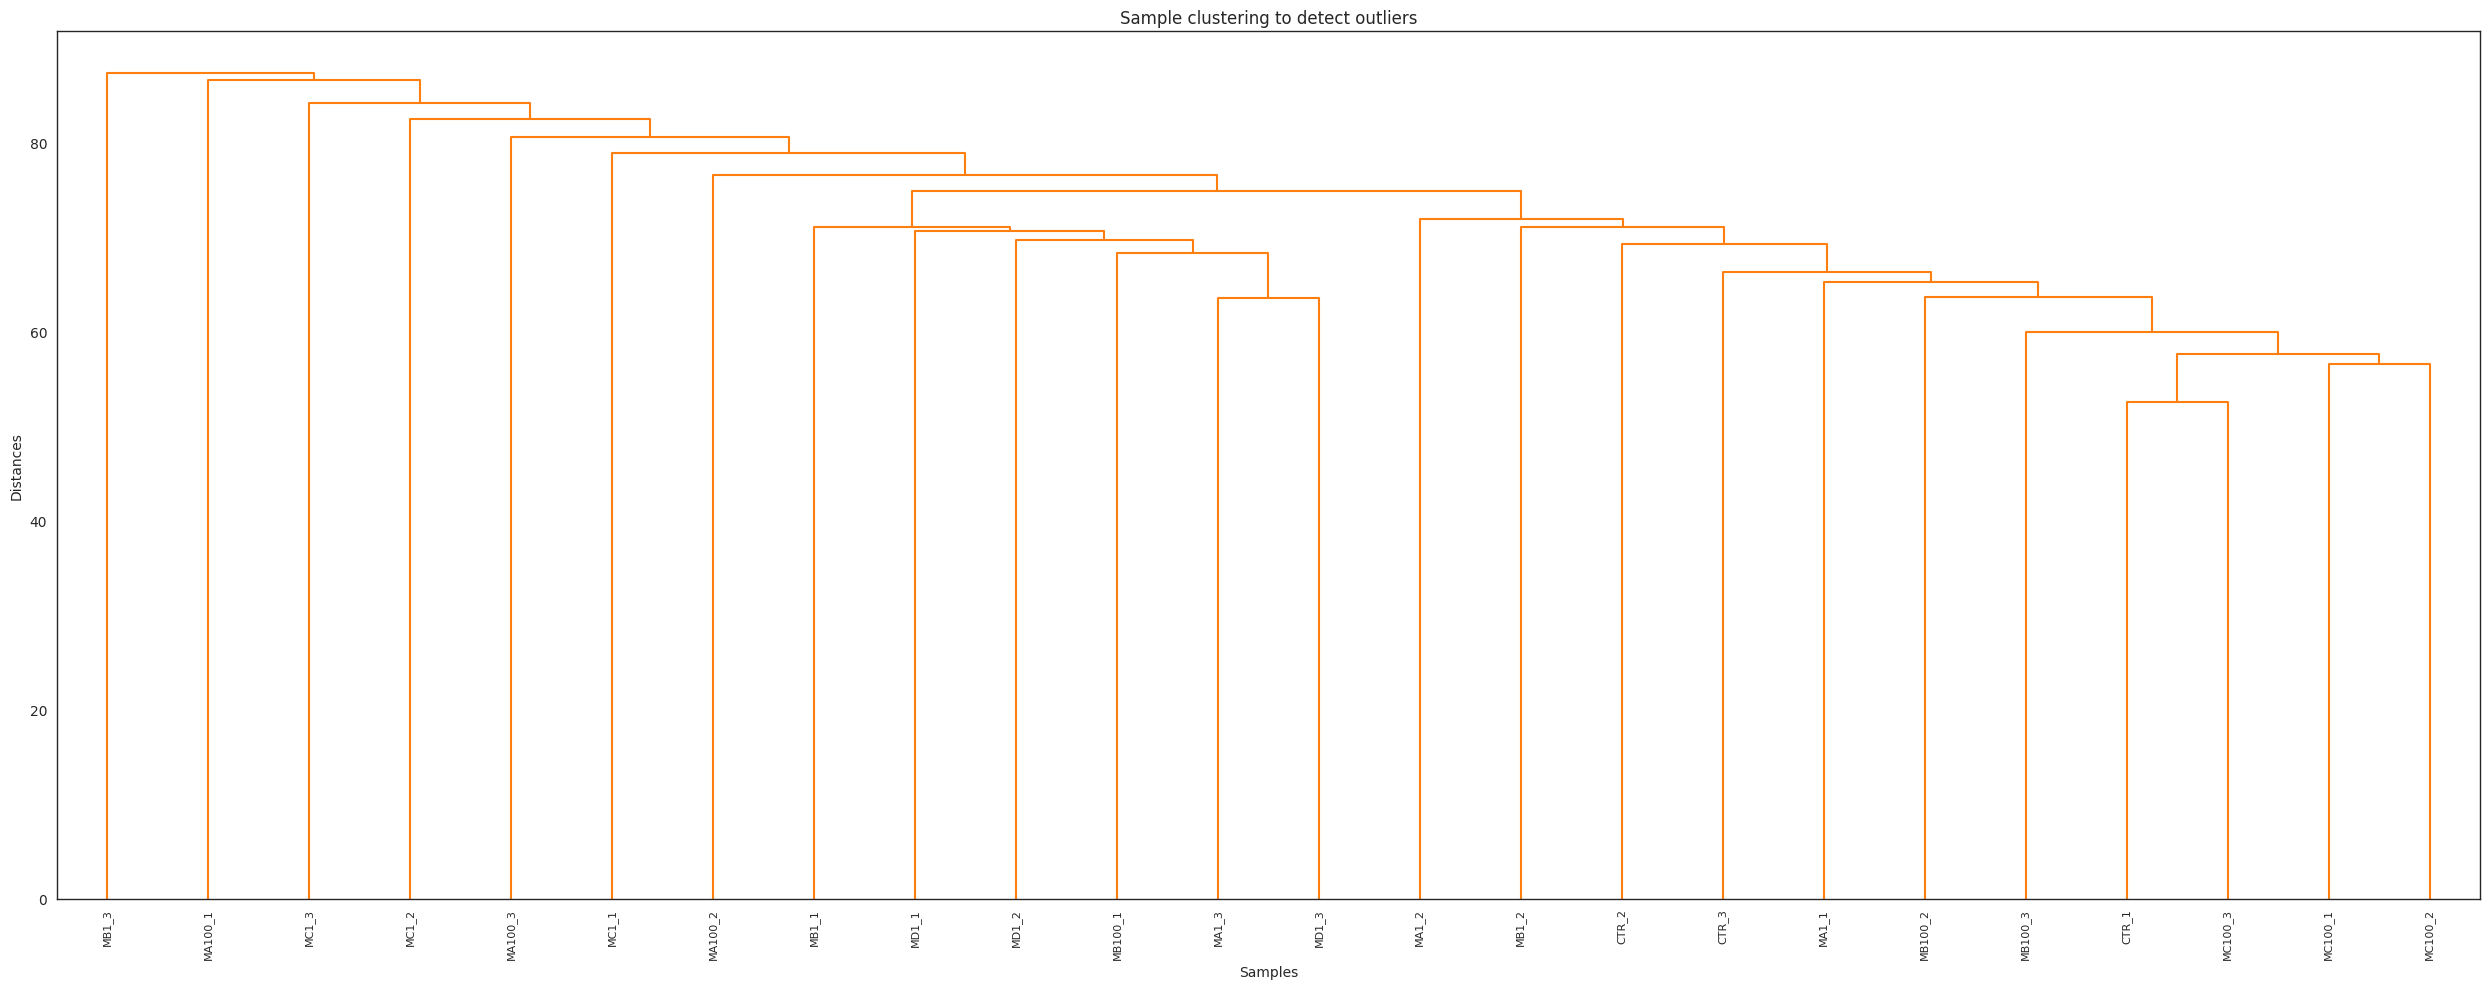

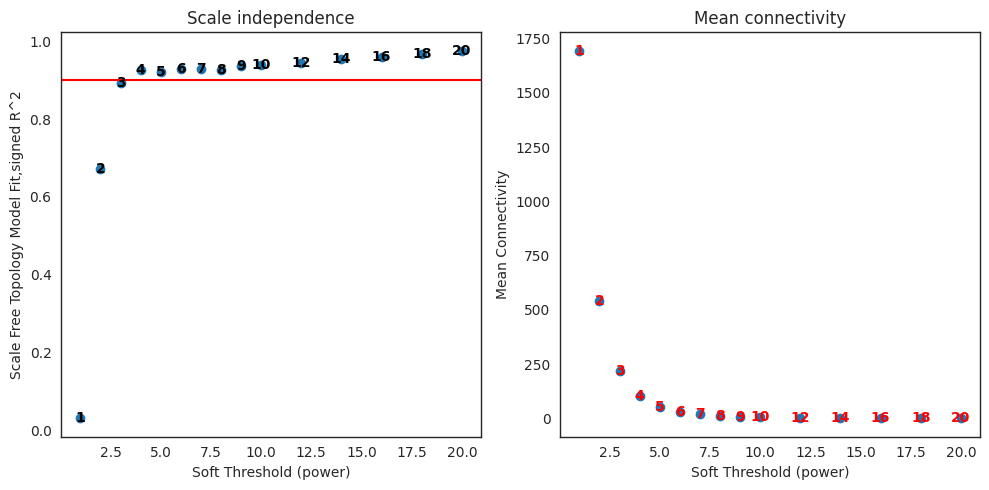

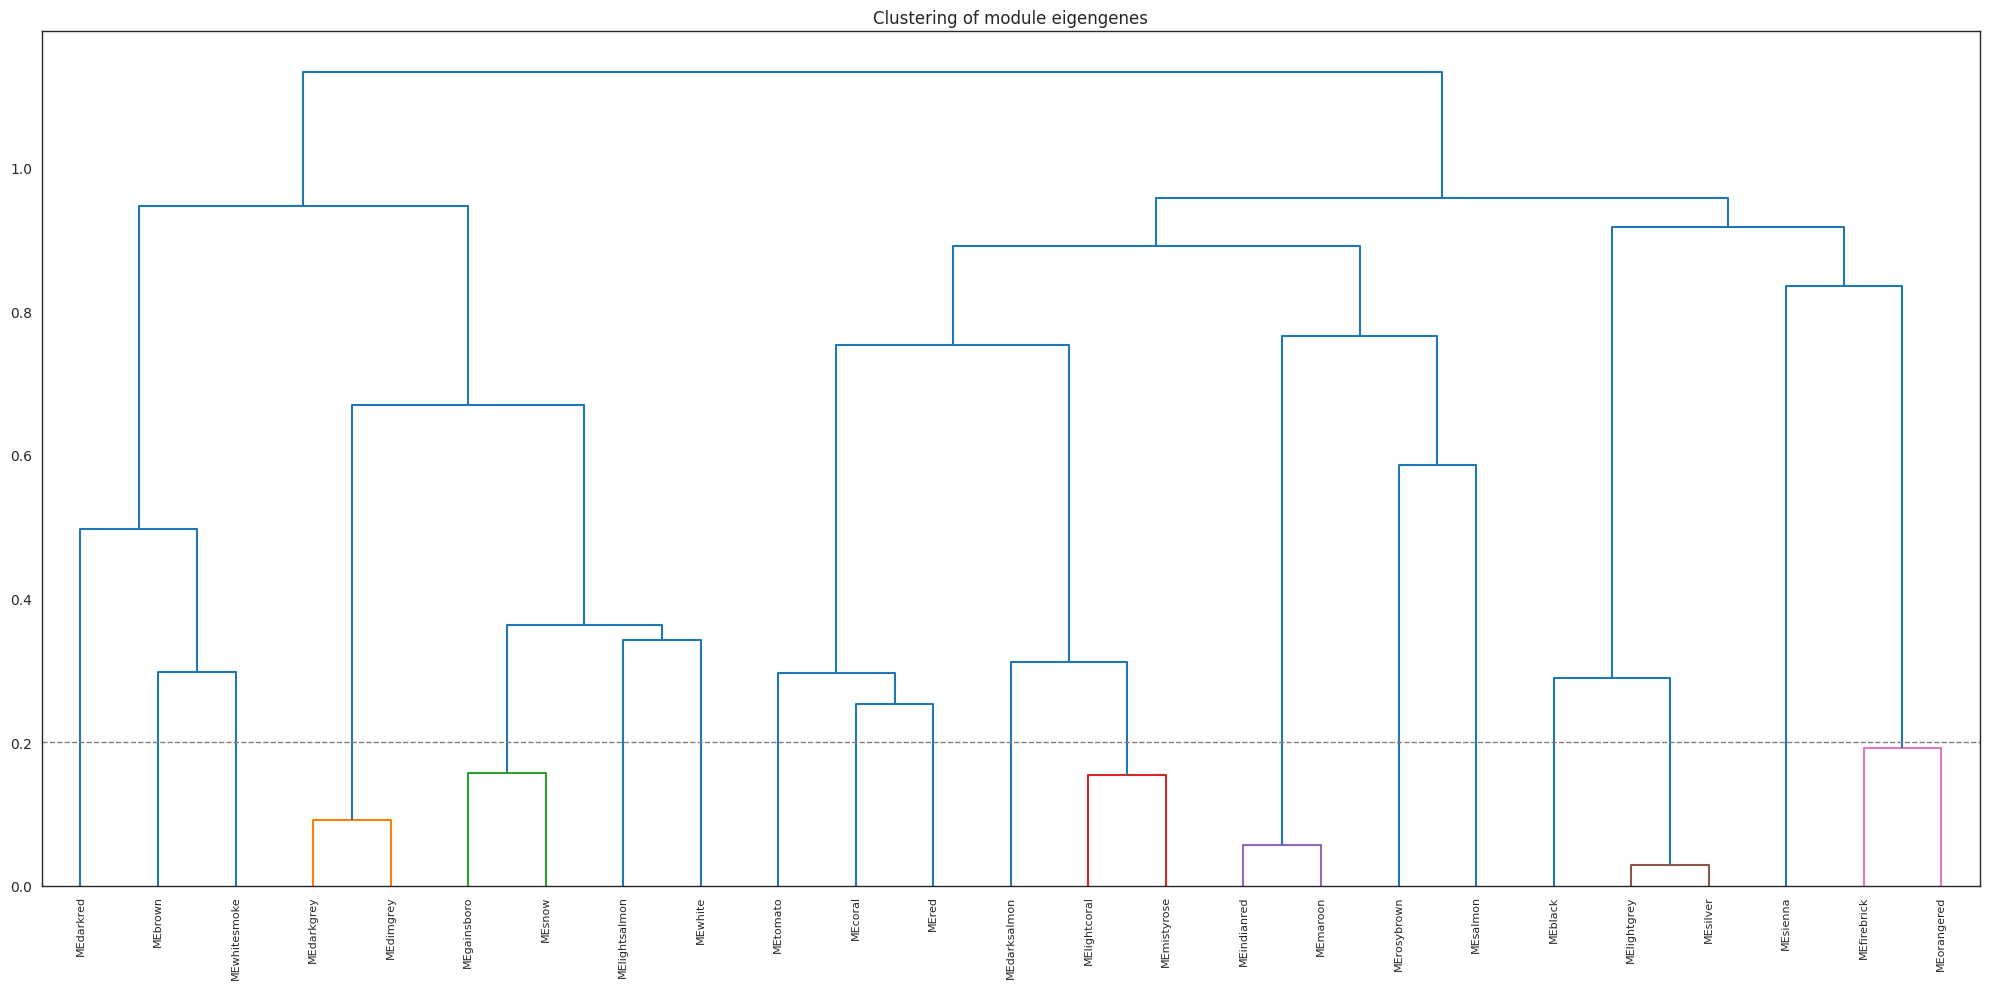

In [7]:
# Rodar WGCNA

pyw.runWGCNA()

if hasattr(pyw, "saveWGCNA"):
    pyw.saveWGCNA()

print("WGCNA executada com sucesso.")

## Inspeção dos Resultados

In [8]:
# Verificar os principais atributos do objeto PyWGCNA após a execução

print("type(pyw.datExpr):", type(getattr(pyw, "datExpr", None)))
print("shape datExpr:", getattr(getattr(pyw, "datExpr", None), "shape", None))

if hasattr(pyw, "datExpr") and pyw.datExpr is not None:
    print("var columns:", pyw.datExpr.var.columns)
    display(pyw.datExpr.var.head())

type(pyw.datExpr): <class 'anndata._core.anndata.AnnData'>
shape datExpr: (24, 15989)
var columns: Index(['dynamicColors', 'moduleColors', 'moduleLabels'], dtype='object')


,dynamicColors,moduleColors,moduleLabels
gene_id,,,
ENSG00000000003,black,black,0
ENSG00000000419,lightgrey,lightgrey,10
ENSG00000000457,black,black,0
ENSG00000000460,salmon,salmon,14
ENSG00000001036,lightgrey,lightgrey,10


In [9]:
# Extração de genes e módulos finais obtidos com WGCNA

if not hasattr(pyw, "datExpr") or pyw.datExpr is None:
    raise ValueError("pyw.datExpr não está disponível.")

gene_var = pyw.datExpr.var.copy()

expected_cols = {"dynamicColors", "moduleColors", "moduleLabels"}
missing_cols = expected_cols - set(gene_var.columns)

if missing_cols:
    raise ValueError(f"Colunas esperadas ausentes em pyw.datExpr.var: {missing_cols}")

gene_modules_df = (
    gene_var
    .reset_index()
    .rename(columns={"index": "gene_id"})
    [["gene_id", "dynamicColors", "moduleColors", "moduleLabels"]]
    .copy()
)

gene_modules_df = gene_modules_df.rename(columns={
    "dynamicColors": "dynamic_module",
    "moduleColors": "module",
    "moduleLabels": "module_label"
})

gene_modules_df.to_csv(GENE_MODULES_PATH, index=False)

print("Tabela gene -> módulo salva em:", GENE_MODULES_PATH)
print("Dimensões:", gene_modules_df.shape)

display(gene_modules_df.head())
display(
    gene_modules_df["module"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "module", "module": "n_genes"})
)

Tabela gene -> módulo salva em: ../../data/interim/wgcna/wgcna_gene_modules.csv
Dimensões: (15989, 4)


,gene_id,dynamic_module,module,module_label
0,ENSG00000000003,black,black,0
1,ENSG00000000419,lightgrey,lightgrey,10
2,ENSG00000000457,black,black,0
3,ENSG00000000460,salmon,salmon,14
4,ENSG00000001036,lightgrey,lightgrey,10


,n_genes,count
0,darkgrey,5445
1,black,4732
2,lightgrey,3334
3,gainsboro,701
4,lightsalmon,322
5,whitesmoke,230
6,white,224
7,indianred,204
8,firebrick,191
9,lightcoral,158


In [10]:
# Cálculo dos module eigengenes a partir dos módulos finais

module_eigengenes = {}

for module_name, module_df in gene_modules_df.groupby("module"):
    genes = [g for g in module_df["gene_id"].tolist() if g in expr_wgcna.columns]

    if len(genes) == 0:
        continue

    X = expr_wgcna[genes].copy()

    # Se o módulo tiver apenas 1 gene, usa o próprio perfil
    if X.shape[1] == 1:
        eigengene = X.iloc[:, 0].values.astype(float)
    else:
        pca = PCA(n_components=1, random_state=42)
        eigengene = pca.fit_transform(X.values).ravel()

        # Ajusta o sinal para ficar coerente com o perfil médio do módulo
        mean_profile = X.mean(axis=1).values
        corr_sign = np.corrcoef(eigengene, mean_profile)[0, 1]
        if pd.notna(corr_sign) and corr_sign < 0:
            eigengene = -eigengene

    module_eigengenes[f"ME_{module_name}"] = eigengene

module_eigengenes_df = pd.DataFrame(
    module_eigengenes,
    index=expr_wgcna.index
)

module_eigengenes_df.index.name = "sample_id"
module_eigengenes_df.to_csv(MODULE_EIGENGENES_PATH)

print("Module eigengenes salvos em:", MODULE_EIGENGENES_PATH)
print("Dimensões:", module_eigengenes_df.shape)

display(module_eigengenes_df.head())

Module eigengenes salvos em: ../../data/interim/wgcna/wgcna_module_eigengenes.csv
Dimensões: (24, 19)


,ME_black,ME_brown,ME_coral,ME_darkgrey,ME_darkred,ME_darksalmon,ME_firebrick,ME_gainsboro,ME_indianred,ME_lightcoral,ME_lightgrey,ME_lightsalmon,ME_red,ME_rosybrown,ME_salmon,ME_sienna,ME_tomato,ME_white,ME_whitesmoke
sample_id,,,,,,,,,,,,,,,,,,,
CTR_1,12.303595,-0.829431,1.016737,-14.332511,1.217592,1.717561,-2.040802,-1.043774,-1.266399,-0.672778,6.186687,0.624068,0.359118,0.454012,0.356656,-0.269633,0.045012,0.461502,0.632170
CTR_2,18.330739,0.876466,-0.029836,-14.919267,-0.623737,-0.152518,1.349048,-3.220376,-0.584240,-1.202522,0.958086,0.768905,-0.817247,0.115983,-0.761863,-0.181986,-0.896367,-4.929216,3.718417
CTR_3,16.840785,-0.908814,-1.353900,-19.002983,-0.993476,-0.828111,-0.278241,-3.858361,-2.060840,-0.874350,6.740410,3.364972,-0.242334,-5.132690,0.058435,-0.653889,-1.717351,0.378774,1.382344
MA1_1,4.974902,0.076139,-0.428252,-7.061564,-0.039245,-2.032507,1.308767,-3.935919,-0.467951,2.500783,0.143934,-1.379758,-1.046208,-1.378139,0.026303,0.232754,0.619862,-2.166767,-1.253636
MA1_2,-0.513467,-0.678084,-0.560512,-4.848534,0.884888,0.382929,-0.710230,-0.352214,-0.487479,3.060450,3.073032,-1.889197,-0.387159,-1.227815,-2.725366,1.354419,-0.175900,-0.430908,-4.138704


In [11]:
# Filtrar apenas as amostras tratadas para correlação módulo-traço

metadata_treated = metadata[metadata["is_control"] == False].copy()
module_eigengenes_treated = module_eigengenes_df.loc[metadata_treated.index].copy()

print("Amostras totais:", metadata.shape[0])
print("Amostras tratadas:", metadata_treated.shape[0])
print("Module eigengenes (tratadas):", module_eigengenes_treated.shape)

display(metadata_treated.head())
display(module_eigengenes_treated.head())

Amostras totais: 24
Amostras tratadas: 21
Module eigengenes (tratadas): (21, 19)


,particle_type,particle_size_um,particle_size_nm,concentration_gL,is_control,treatment_status,group,replicate
sample_id,,,,,,,,
MA1_1,polystyrene,1.0,1000.0,0.1,False,treated,MA1,1
MA1_2,polystyrene,1.0,1000.0,0.1,False,treated,MA1,2
MA1_3,polystyrene,1.0,1000.0,0.1,False,treated,MA1,3
MA100_1,polystyrene,0.1,100.0,0.1,False,treated,MA100,1
MA100_2,polystyrene,0.1,100.0,0.1,False,treated,MA100,2


,ME_black,ME_brown,ME_coral,ME_darkgrey,ME_darkred,ME_darksalmon,ME_firebrick,ME_gainsboro,ME_indianred,ME_lightcoral,ME_lightgrey,ME_lightsalmon,ME_red,ME_rosybrown,ME_salmon,ME_sienna,ME_tomato,ME_white,ME_whitesmoke
sample_id,,,,,,,,,,,,,,,,,,,
MA1_1,4.974902,0.076139,-0.428252,-7.061564,-0.039245,-2.032507,1.308767,-3.935919,-0.467951,2.500783,0.143934,-1.379758,-1.046208,-1.378139,0.026303,0.232754,0.619862,-2.166767,-1.253636
MA1_2,-0.513467,-0.678084,-0.560512,-4.848534,0.884888,0.382929,-0.710230,-0.352214,-0.487479,3.060450,3.073032,-1.889197,-0.387159,-1.227815,-2.725366,1.354419,-0.175900,-0.430908,-4.138704
MA1_3,-4.783968,0.311643,0.848131,9.662280,0.744661,-0.950699,1.867793,8.185528,2.005244,-2.960996,10.237615,2.921870,1.327694,1.402455,1.620100,0.183699,0.466429,4.015262,0.835262
MA100_1,-13.970371,3.186086,-2.724270,24.107453,-1.475435,1.338622,8.831847,8.248905,-2.784545,-4.961475,-13.567763,6.301829,-3.992170,-2.261731,-1.947716,-0.828656,-1.952856,2.543343,5.404461
MA100_2,-7.051155,1.819673,-2.185680,7.743068,1.035890,0.317936,-1.179239,0.194043,-4.923991,-0.087750,-7.973922,1.288799,-0.341876,-2.180213,-1.432586,-1.149940,0.624885,-1.085596,1.844141


In [12]:
# Montar traços de interesse para correlação

metadata_treated = metadata_treated.copy()

# Variável binária principal para distinguir 100 nm de 1 µm
metadata_treated["is_100nm"] = (metadata_treated["particle_size_nm"] == 100).astype(int)

# Dummies por grupo para leitura mais fina no heatmap
group_dummies_treated = pd.get_dummies(metadata_treated["group"], prefix="group")

# Traits não redundantes
traits_numeric_treated = pd.concat([
    metadata_treated[[
        "particle_size_um",
        "concentration_gL",
        "is_100nm",
    ]],
    group_dummies_treated
], axis=1)

print("Traits numéricos (tratadas):", traits_numeric_treated.shape)
display(traits_numeric_treated.head())

Traits numéricos (tratadas): (21, 10)


,particle_size_um,concentration_gL,is_100nm,group_MA1,group_MA100,group_MB1,group_MB100,group_MC1,group_MC100,group_MD1
sample_id,,,,,,,,,,
MA1_1,1.0,0.1,0,True,False,False,False,False,False,False
MA1_2,1.0,0.1,0,True,False,False,False,False,False,False
MA1_3,1.0,0.1,0,True,False,False,False,False,False,False
MA100_1,0.1,0.1,1,False,True,False,False,False,False,False
MA100_2,0.1,0.1,1,False,True,False,False,False,False,False


In [13]:
# Correlação módulo-traço

def safe_pearsonr(x, y):
    x = pd.Series(x).astype(float)
    y = pd.Series(y).astype(float)

    mask = x.notna() & y.notna()

    if mask.sum() < 3:
        return np.nan, np.nan

    if x[mask].nunique() < 2 or y[mask].nunique() < 2:
        return np.nan, np.nan

    r, p = pearsonr(x[mask], y[mask])
    return r, p

corr_matrix_treated = pd.DataFrame(
    index=module_eigengenes_treated.columns,
    columns=traits_numeric_treated.columns,
    dtype=float
)

pval_matrix_treated = pd.DataFrame(
    index=module_eigengenes_treated.columns,
    columns=traits_numeric_treated.columns,
    dtype=float
)

for me_col in module_eigengenes_treated.columns:
    for trait_col in traits_numeric_treated.columns:
        r, p = safe_pearsonr(
            module_eigengenes_treated[me_col],
            traits_numeric_treated[trait_col]
        )
        corr_matrix_treated.loc[me_col, trait_col] = r
        pval_matrix_treated.loc[me_col, trait_col] = p

print("Matriz de correlação:", corr_matrix_treated.shape)
print("Matriz de p-values:", pval_matrix_treated.shape)

display(corr_matrix_treated)
display(pval_matrix_treated)

Matriz de correlação: (19, 10)
Matriz de p-values: (19, 10)


,particle_size_um,concentration_gL,is_100nm,group_MA1,group_MA100,group_MB1,group_MB100,group_MC1,group_MC100,group_MD1
ME_black,-0.483998,-0.306085,0.483998,0.074662,-0.299758,-0.034492,0.301684,-0.387166,0.682551,-0.337480
ME_brown,-0.183142,0.227979,0.183142,-0.029473,0.542853,-0.137896,-0.128033,0.343214,-0.155819,-0.434846
ME_coral,0.152014,0.026527,-0.152014,-0.014212,-0.214913,0.102557,-0.010071,-0.383711,0.010004,0.510348
ME_darkgrey,0.218545,0.357076,-0.218545,-0.099610,0.464276,-0.133352,-0.227383,0.345546,-0.545962,0.196486
ME_darkred,-0.045804,0.119162,0.045804,0.112298,-0.086692,-0.385708,0.062933,-0.088249,0.088535,0.296883
ME_darksalmon,-0.478604,-0.260736,0.478604,-0.210663,0.116829,-0.241142,-0.022477,0.170036,0.582496,-0.395079
ME_firebrick,-0.200769,0.233312,0.200769,0.088551,0.155602,-0.020268,0.025546,-0.424452,0.102783,0.072238
ME_gainsboro,-0.293683,0.401813,0.293683,0.082493,0.375551,-0.755221,-0.012264,0.066242,0.052043,0.191156
ME_indianred,0.308465,-0.147844,-0.308465,0.018047,-0.408355,0.377669,-0.029296,-0.325102,0.001415,0.365623
ME_lightcoral,0.250549,-0.119999,-0.250549,0.135124,-0.369762,0.432573,0.065735,-0.304539,-0.050303,0.091173


,particle_size_um,concentration_gL,is_100nm,group_MA1,group_MA100,group_MB1,group_MB100,group_MC1,group_MC100,group_MD1
ME_black,0.026204,0.177202,0.026204,0.747724,0.186784,0.882005,0.183831,0.082928,0.000652,0.134621
ME_brown,0.426831,0.320257,0.426831,0.899082,0.010995,0.551119,0.580210,0.127709,0.500016,0.048840
ME_coral,0.510666,0.909130,0.510666,0.951246,0.349507,0.658225,0.965441,0.085950,0.965672,0.018088
ME_darkgrey,0.341224,0.112053,0.341224,0.667493,0.033986,0.564439,0.321558,0.124972,0.010457,0.393302
ME_darkred,0.843711,0.606923,0.843711,0.627932,0.708664,0.084194,0.786387,0.703656,0.702739,0.191252
ME_darksalmon,0.028176,0.253635,0.028176,0.359346,0.614033,0.292329,0.922960,0.461194,0.005592,0.076304
ME_firebrick,0.382860,0.308755,0.382860,0.702688,0.500620,0.930512,0.912477,0.055138,0.657514,0.755669
ME_gainsboro,0.196311,0.070987,0.196311,0.722225,0.093412,0.000076,0.957923,0.775426,0.822726,0.406515
ME_indianred,0.173685,0.522466,0.173685,0.938112,0.066092,0.091432,0.899688,0.150438,0.995143,0.103122
ME_lightcoral,0.273321,0.604380,0.273321,0.559227,0.098988,0.050168,0.777104,0.179511,0.828567,0.694288


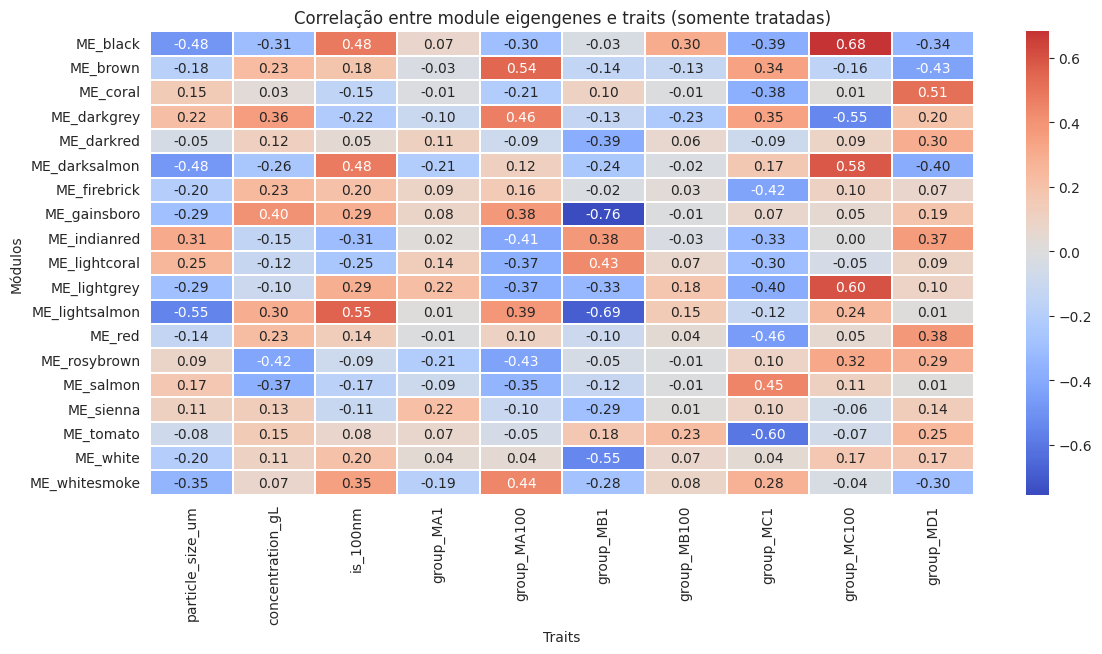

Heatmap salvo em: ../../data/interim/wgcna/wgcna_module_trait_heatmap_treated.png


In [14]:
# Heatmap da correlação entre módulo-traço

plt.figure(figsize=(12, max(5, len(corr_matrix_treated) * 0.35)))
sns.heatmap(
    corr_matrix_treated.astype(float),
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.3
)
plt.title("Correlação entre module eigengenes e traits (somente tratadas)")
plt.xlabel("Traits")
plt.ylabel("Módulos")
plt.tight_layout()
plt.savefig(HEATMAP_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Heatmap salvo em:", HEATMAP_PATH)

## Consolidação dos Resultados do WGCNA

In [15]:
# Salvamento dos resultados sem controles

module_eigengenes_treated.to_csv(MODULE_EIGENGENES_TREATED_PATH)
corr_matrix_treated.to_csv(MODULE_TRAIT_CORR_PATH)
pval_matrix_treated.to_csv(MODULE_TRAIT_PVAL_PATH)

print("Arquivos salvos:")
print("-", MODULE_EIGENGENES_TREATED_PATH)
print("-", MODULE_TRAIT_CORR_PATH)
print("-", MODULE_TRAIT_PVAL_PATH)

Arquivos salvos:
- ../../data/interim/wgcna/wgcna_module_eigengenes_treated.csv
- ../../data/interim/wgcna/wgcna_module_trait_correlations_treated.csv
- ../../data/interim/wgcna/wgcna_module_trait_pvalues_treated.csv


In [16]:
# Resumo dos módulos mais associados aos traços de interesse

summary_rows = []

for module_name in corr_matrix_treated.index:
    row = {"module": module_name}

    for trait in ["particle_size_um", "concentration_gL", "is_100nm"]:
        if trait in corr_matrix_treated.columns:
            row[f"corr_{trait}"] = corr_matrix_treated.loc[module_name, trait]
            row[f"pval_{trait}"] = pval_matrix_treated.loc[module_name, trait]

    summary_rows.append(row)

module_summary_df = pd.DataFrame(summary_rows)
module_summary_df.to_csv(MODULE_SUMMARY_PATH, index=False)

print("Resumo dos módulos salvo em:", MODULE_SUMMARY_PATH)
display(module_summary_df.sort_values("pval_particle_size_um", na_position="last").head(15))

Resumo dos módulos salvo em: ../../data/interim/wgcna/wgcna_module_summary.csv


,module,corr_particle_size_um,pval_particle_size_um,corr_concentration_gL,pval_concentration_gL,corr_is_100nm,pval_is_100nm
11,ME_lightsalmon,-0.553397,0.009258,0.299224,0.187609,0.553397,0.009258
0,ME_black,-0.483998,0.026204,-0.306085,0.177202,0.483998,0.026204
5,ME_darksalmon,-0.478604,0.028176,-0.260736,0.253635,0.478604,0.028176
18,ME_whitesmoke,-0.346063,0.124371,0.070647,0.760897,0.346063,0.124371
8,ME_indianred,0.308465,0.173685,-0.147844,0.522466,-0.308465,0.173685
7,ME_gainsboro,-0.293683,0.196311,0.401813,0.070987,0.293683,0.196311
10,ME_lightgrey,-0.290864,0.200841,-0.096148,0.678443,0.290864,0.200841
9,ME_lightcoral,0.250549,0.273321,-0.119999,0.604380,-0.250549,0.273321
3,ME_darkgrey,0.218545,0.341224,0.357076,0.112053,-0.218545,0.341224
17,ME_white,-0.204312,0.374342,0.106017,0.647401,0.204312,0.374342
